# Clinical Trials Data Analysis using the AACT Database
Project Overview
This project explores publicly available clinical trial data from the AACT (Aggregate Analysis of ClinicalTrials.gov) database. The goal is to perform exploratory data analysis to understand global patterns in clinical research, including disease focus, sponsor activity, geographic distribution of trials, and temporal trends.

### The analysis focuses on four main questions:
1.Which diseases are most frequently studied in clinical trials?
2.Which types of sponsors are most active in clinical research?
3.How are clinical trials distributed geographically across countries?
4.How has the number of clinical trials evolved over time?

### Dataset Description
The analysis uses several tables from the AACT database, which compiles structured information from ClinicalTrials.gov. The following tables were integrated:
studies – Core information about each clinical trial
conditions – Diseases or conditions studied in trials
interventions – Drugs, devices, or treatments evaluated
facilities – Locations where trials are conducted
sponsors – Organizations responsible for trials

### Data Processing Pipeline
The analysis pipeline includes the following steps:
Data loading – Importing tables from the AACT dataset into Python using pandas.
Data cleaning – Removing missing identifiers and standardizing data types.
Table merging – Joining multiple tables using the clinical trial identifier (nct_id).
Feature selection – Keeping only relevant variables for analytical tasks.
Feature engineering – Extracting time variables and deriving disease categories.
Exploratory analysis – Generating visualizations to identify trends and patterns.

# Key Findings

## Clinical Trial Disease Focus
The analysis reveals that certain disease areas dominate clinical trial research activity. These trends reflect the prioritization of research funding and pharmaceutical development efforts toward high-impact or high-prevalence diseases.

## Sponsor Activity
Industry sponsors represent a major share of clinical trial activity, while academic institutions and government agencies also contribute significantly to research efforts.
This distribution highlights the collaborative nature of biomedical research between public and private sectors.

## Global Distribution of Trials
Clinical trials are concentrated in specific regions, particularly in countries with strong biomedical research infrastructure. This reflects differences in regulatory frameworks, research funding availability, and healthcare system capacity.

## Growth of Clinical Trials Over Time
The number of clinical trials has increased over time, reflecting the expansion of biomedical research and the growing demand for new therapies.
Advances in biotechnology, regulatory incentives, and global health challenges have contributed to this growth.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

studies = pd.read_csv("../data/studies.txt", sep="|", low_memory=False)
conditions = pd.read_csv("../data/conditions.txt", sep="|", low_memory=False)
interventions = pd.read_csv("../data/interventions.txt", sep="|", low_memory=False)
facilities = pd.read_csv("../data/facilities.txt", sep="|", low_memory=False)
sponsors = pd.read_csv("../data/sponsors.txt", sep="|", low_memory=False)

studies = studies.dropna(subset=["nct_id"])
conditions = conditions.dropna(subset=["nct_id"])
interventions = interventions.dropna(subset=["nct_id"])
facilities = facilities.dropna(subset=["nct_id"])
sponsors = sponsors.dropna(subset=["nct_id"])

In [3]:
trial_df = studies.merge(conditions,on="nct_id",how="left")
trial_df = trial_df.merge(interventions,on="nct_id",how="left")
trial_df = trial_df.merge(facilities,on="nct_id",how="left")
sponsors = sponsors.loc[:, ["nct_id", "agency_class", "lead_or_collaborator"]]
trial_df = trial_df.merge(sponsors,on="nct_id",how="left")

In [ ]:
keep_columns = [
    "nct_id",
    "brief_title",
    "condition"
    "study_type",
    "phase",
    "overall_status",
    "enrollment",
    "number_of_arms",
    "number_of_groups",
    "start_date",
    "completion_date",
    "intervention_type",
    "name_y",
    "country",
    "city",
    "agency_class",
    "lead_or_collaborator"
]

trial_df = trial_df[keep_columns]

In [5]:
trial_df["start_date"] = pd.to_datetime(trial_df["start_date"], errors="coerce")
trial_df["completion_date"] = pd.to_datetime(trial_df["completion_date"], errors="coerce")

In [6]:
trial_df["year"] = trial_df["start_date"].dt.year

### Preparing the master dataframe

Removed records with missing NCT identifiers

Merged multiple clinical trial tables into a unified dataset while retaining only analytically relevant columns to reduce memory usage

Excluded administrative metadata fields from the analysis

Converted date variables to datetime format and extracted year-level features for temporal analysis

### Top 10 Disease Feature

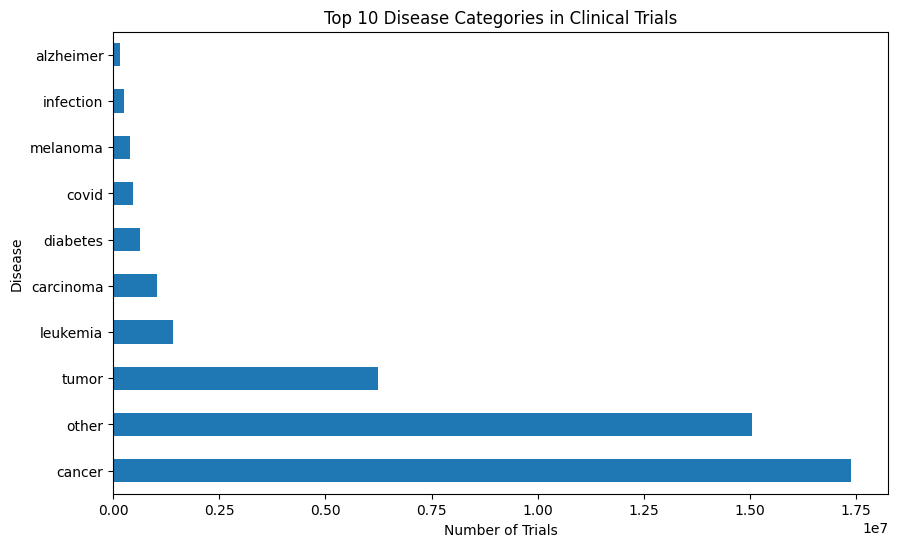

In [7]:
disease_keywords = [
    "cancer","tumor","leukemia","diabetes",
    "alzheimer","covid","infection",
    "carcinoma","melanoma"
]

def extract_disease(text):
    text = str(text).lower()
    for keyword in disease_keywords:
        if keyword in text:
            return keyword
    return "other"

trial_df["disease"] = trial_df["brief_title"].apply(extract_disease)

trial_df["disease"].value_counts().head(10).plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Top 10 Disease Categories in Clinical Trials")
plt.xlabel("Number of Trials")
plt.ylabel("Disease")
plt.show()

### Sponsor Activity

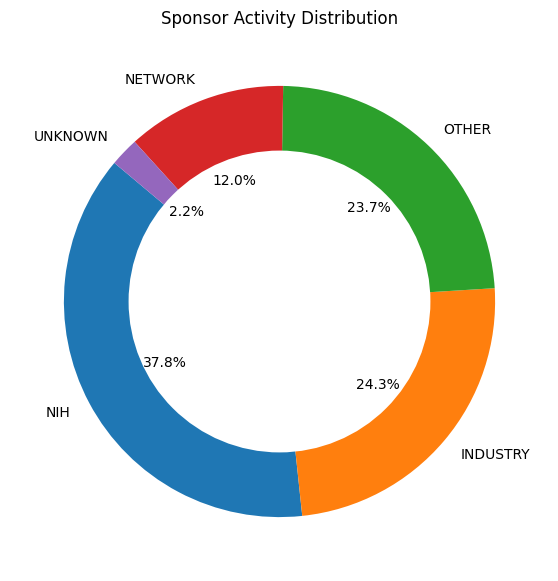

In [8]:
import matplotlib.pyplot as plt

# Compute counts
sponsor_counts = trial_df["agency_class"].value_counts()

# Remove categories < 2%
sponsor_counts = sponsor_counts[sponsor_counts / sponsor_counts.sum() >= 0.02]

plt.figure(figsize=(7,7))

plt.pie(
    sponsor_counts,
    labels=sponsor_counts.index,
    autopct="%1.1f%%",
    startangle=140
)

# Donut style center
centre_circle = plt.Circle((0,0),0.70,fc='white')
plt.gca().add_artist(centre_circle)

plt.title("Sponsor Activity Distribution")
plt.show()

### Country Distribution

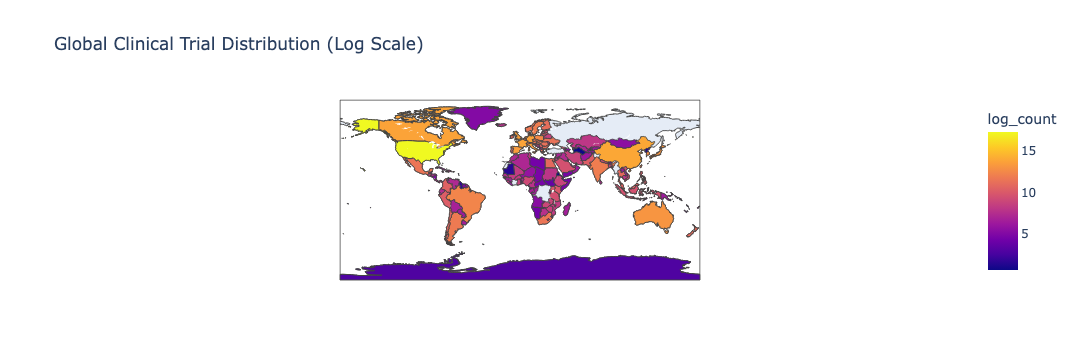

In [13]:
import pycountry

def country_to_iso3(country):
    try:
        return pycountry.countries.lookup(country).alpha_3
    except:
        return None

trial_df["country_iso3"] = trial_df["country"].apply(country_to_iso3)

import numpy as np

country_counts = trial_df["country_iso3"].value_counts().reset_index()
country_counts.columns = ["country_iso3", "count"]

country_counts["log_count"] = np.log1p(country_counts["count"])

import plotly.express as px

fig = px.choropleth(
    country_counts,
    locations="country_iso3",
    locationmode="ISO-3",
    color="log_count",
    title="Global Clinical Trial Distribution (Log Scale)"
)

fig.show()

#### This code generates distribution map on raw counts and color legend is too compressed because data distribution is extremely skewed
import pycountry

def country_to_iso3(country):
    try:
        return pycountry.countries.lookup(country).alpha_3
    except:
        return None

trial_df["country_iso3"] = trial_df["country"].apply(country_to_iso3)

import plotly.express as px
import plotly.io as pio
pio.renderers.default = "notebook"

#### Count trials per country (use ISO3 column created above)
country_counts = trial_df["country_iso3"].value_counts().reset_index()

country_counts.columns = ["country_iso3", "count"]

fig = px.choropleth(
    country_counts,
    locations="country_iso3",
    locationmode="ISO-3",
    color="count",
    title="Global Clinical Trial Distribution"
)

fig.show()

### Trials Over Time

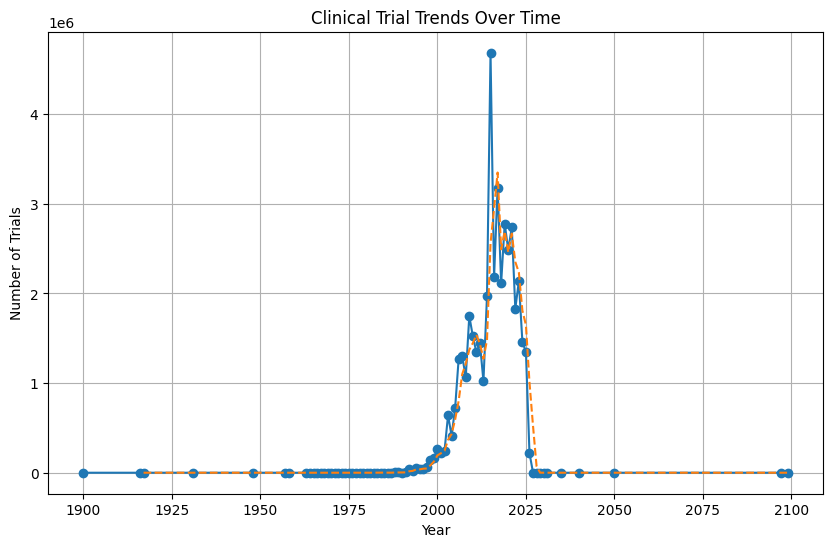

In [80]:
trend_data = trial_df["year"].value_counts().sort_index()

plt.figure(figsize=(10,6))

plt.plot(trend_data.index, trend_data.values, marker="o")

# rolling smoothing
rolling_avg = trend_data.rolling(window=3).mean()

plt.plot(trend_data.index, rolling_avg, linestyle="--")

plt.title("Clinical Trial Trends Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Trials")
plt.grid()
plt.show()